# 📊 OnePilot — Forecasting | Notebook 1 : Pipeline de Données
**Source** : Northwind_PBI (MSSQL) via API OnePilot `/dashboard/data`  
**Output** : `/tmp/northwind_monthly.csv` + `/tmp/northwind_weekly.csv`

In [12]:
import requests, time, json
import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller
import warnings; warnings.filterwarnings('ignore')

# ── Config ────────────────────────────────────────────────────────
BASE_URL   = 'http://onepilot_api:8000'
SOURCE_SXA = '85a0ef4b-d9af-494f-b24f-ff710c21ba43'
SOURCE_NW  = '3896cf72-00e3-4528-8fd5-e65395be8d5f'

# Style graphiques OnePilot
plt.rcParams.update({
    'figure.facecolor': '#060a0e', 'axes.facecolor': '#0d1520',
    'axes.edgecolor': '#182336',   'text.color': '#d8e8f2',
    'axes.labelcolor': '#7ea4be',  'xtick.color': '#7ea4be',
    'ytick.color': '#7ea4be',      'grid.color': '#182336',
    'grid.linestyle': '--',        'grid.alpha': 0.5
})

# ── Test connexion API ────────────────────────────────────────────
try:
    r = requests.get(f'{BASE_URL}/health', timeout=5)
    print(f'✅ API connectée — status={r.status_code}')
except Exception as e:
    print(f'❌ Connexion échouée : {e}')
print('✅ Imports OK')

✅ API connectée — status=200
✅ Imports OK


In [6]:
# ── Helper : exécuter du SQL via /dashboard/data ──────────────────
def run_sql(sql, source_id=SOURCE_NW, limit=10000):
    """Exécute un SQL sur une source OnePilot et retourne un DataFrame."""
    resp = requests.post(
        f'{BASE_URL}/dashboard/data',
        json={'sql': sql, 'source_id': source_id, 'limit': limit},
        timeout=30
    )
    data = resp.json()
    if 'rows' not in data:
        raise Exception(f"Erreur API : {data}")
    return pd.DataFrame(data['rows'])

print('✅ Helper run_sql() prêt')

✅ Helper run_sql() prêt


In [7]:
# ── Exploration du schéma ─────────────────────────────────────────
df_tables = run_sql("""
    SELECT TABLE_NAME, TABLE_TYPE 
    FROM INFORMATION_SCHEMA.TABLES 
    WHERE TABLE_TYPE = 'BASE TABLE'
    ORDER BY TABLE_NAME
""")
print(f'📋 Tables Northwind ({len(df_tables)}) :')
print(df_tables.to_string(index=False))

📋 Tables Northwind (12) :
          TABLE_NAME TABLE_TYPE
          Categories BASE TABLE
CustomerCustomerDemo BASE TABLE
CustomerDemographics BASE TABLE
           Customers BASE TABLE
           Employees BASE TABLE
 EmployeeTerritories BASE TABLE
       Order Details BASE TABLE
              Orders BASE TABLE
            Products BASE TABLE
              Region BASE TABLE
            Shippers BASE TABLE
         Territories BASE TABLE


In [8]:
# ── Détecter le nom exact de la table Order Details ───────────────
table_details = None
for name in ['Order Details', 'OrderDetails', 'order_details']:
    try:
        df_chk = run_sql(f"SELECT COUNT(*) as n FROM INFORMATION_SCHEMA.TABLES WHERE TABLE_NAME='{name}'")
        if df_chk['n'].iloc[0] > 0:
            table_details = name
            print(f'✅ Table détails : [{name}]')
            break
    except: pass

# Plage temporelle
df_range = run_sql("SELECT MIN(OrderDate) AS date_min, MAX(OrderDate) AS date_max, COUNT(*) AS nb FROM Orders")
print(f'\n📅 Plage Orders :')
print(df_range.to_string(index=False))

✅ Table détails : [Order Details]

📅 Plage Orders :
           date_min            date_max  nb
1996-07-04T00:00:00 1998-05-06T00:00:00 830


In [9]:
# ── Extraction mensuelle ──────────────────────────────────────────
tbl = f'[{table_details}]' if table_details else '[Order Details]'

df_monthly = run_sql(f"""
SELECT 
    CAST(YEAR(o.OrderDate) AS VARCHAR) + '-' +
        RIGHT('0' + CAST(MONTH(o.OrderDate) AS VARCHAR), 2) AS periode,
    YEAR(o.OrderDate)  AS annee,
    MONTH(o.OrderDate) AS mois,
    COUNT(DISTINCT o.OrderID) AS nb_commandes,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)), 2) AS revenu
FROM Orders o
JOIN {tbl} od ON o.OrderID = od.OrderID
WHERE o.OrderDate IS NOT NULL
GROUP BY YEAR(o.OrderDate), MONTH(o.OrderDate)
ORDER BY annee, mois
""")

df_monthly['date'] = pd.to_datetime(df_monthly['periode'])
df_monthly = df_monthly.set_index('date').sort_index()
df_monthly['revenu'] = pd.to_numeric(df_monthly['revenu'])

print(f'✅ Données mensuelles')
print(f'   Points   : {len(df_monthly)}')
print(f'   Période  : {df_monthly.index.min().strftime("%Y-%m")} → {df_monthly.index.max().strftime("%Y-%m")}')
print(f'   Min/Max  : {df_monthly["revenu"].min():,.0f} € / {df_monthly["revenu"].max():,.0f} €')
display(df_monthly.head(3))

✅ Données mensuelles
   Points   : 23
   Période  : 1996-07 → 1998-05
   Min/Max  : 18,334 € / 123,799 €


,periode,annee,mois,nb_commandes,revenu
date,,,,,
1996-07-01,1996-07,1996,7,22,27861.89
1996-08-01,1996-08,1996,8,25,25485.27
1996-09-01,1996-09,1996,9,23,26381.40


In [10]:
# ── Extraction hebdomadaire (pour LSTM) ───────────────────────────
df_weekly = run_sql(f"""
SELECT 
    YEAR(o.OrderDate)           AS annee,
    DATEPART(WEEK, o.OrderDate) AS semaine,
    MIN(o.OrderDate)            AS date_debut,
    COUNT(DISTINCT o.OrderID)   AS nb_commandes,
    ROUND(SUM(od.UnitPrice * od.Quantity * (1 - od.Discount)), 2) AS revenu
FROM Orders o
JOIN {tbl} od ON o.OrderID = od.OrderID
WHERE o.OrderDate IS NOT NULL
GROUP BY YEAR(o.OrderDate), DATEPART(WEEK, o.OrderDate)
ORDER BY annee, semaine
""")

df_weekly['date'] = pd.to_datetime(df_weekly['date_debut'])
df_weekly = df_weekly.set_index('date').sort_index()
df_weekly['revenu'] = pd.to_numeric(df_weekly['revenu'])

print(f'✅ Données hebdomadaires')
print(f'   Points   : {len(df_weekly)}')

✅ Données hebdomadaires
   Points   : 99


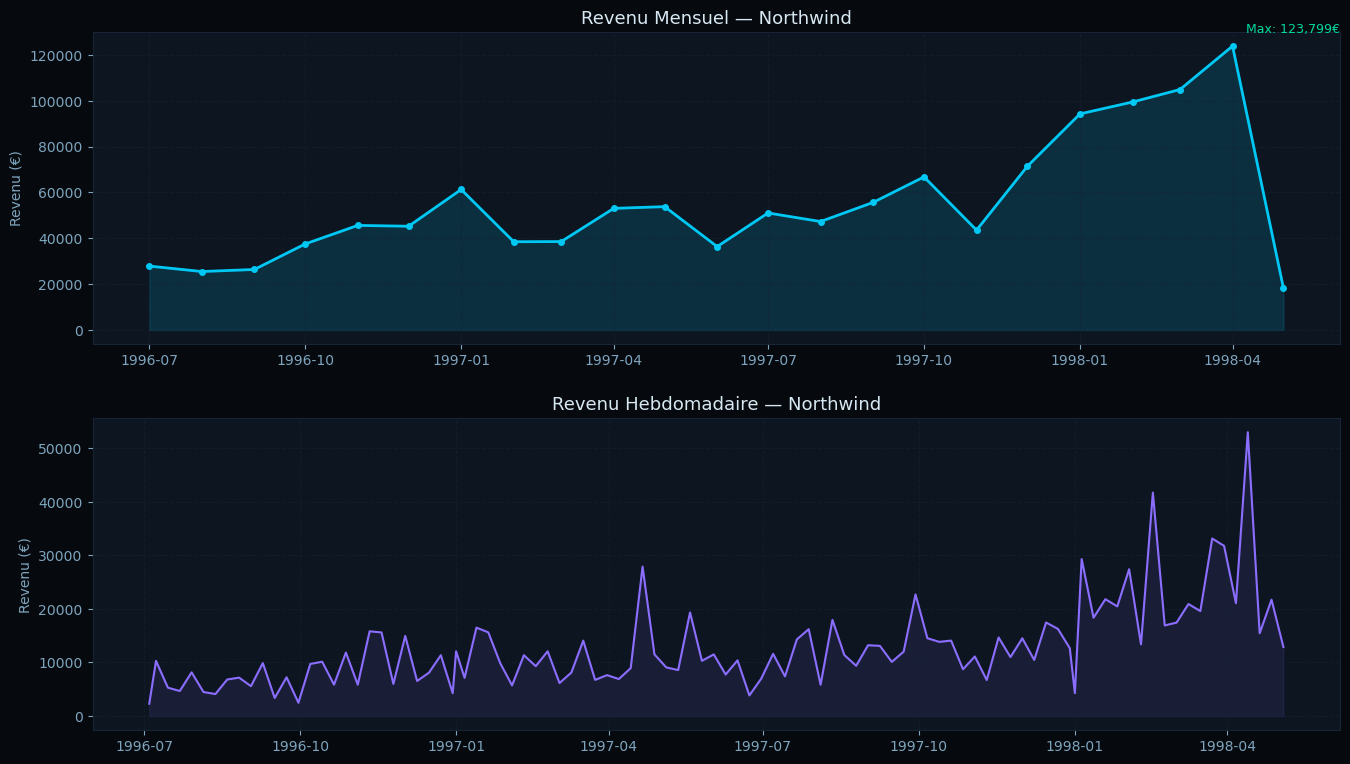

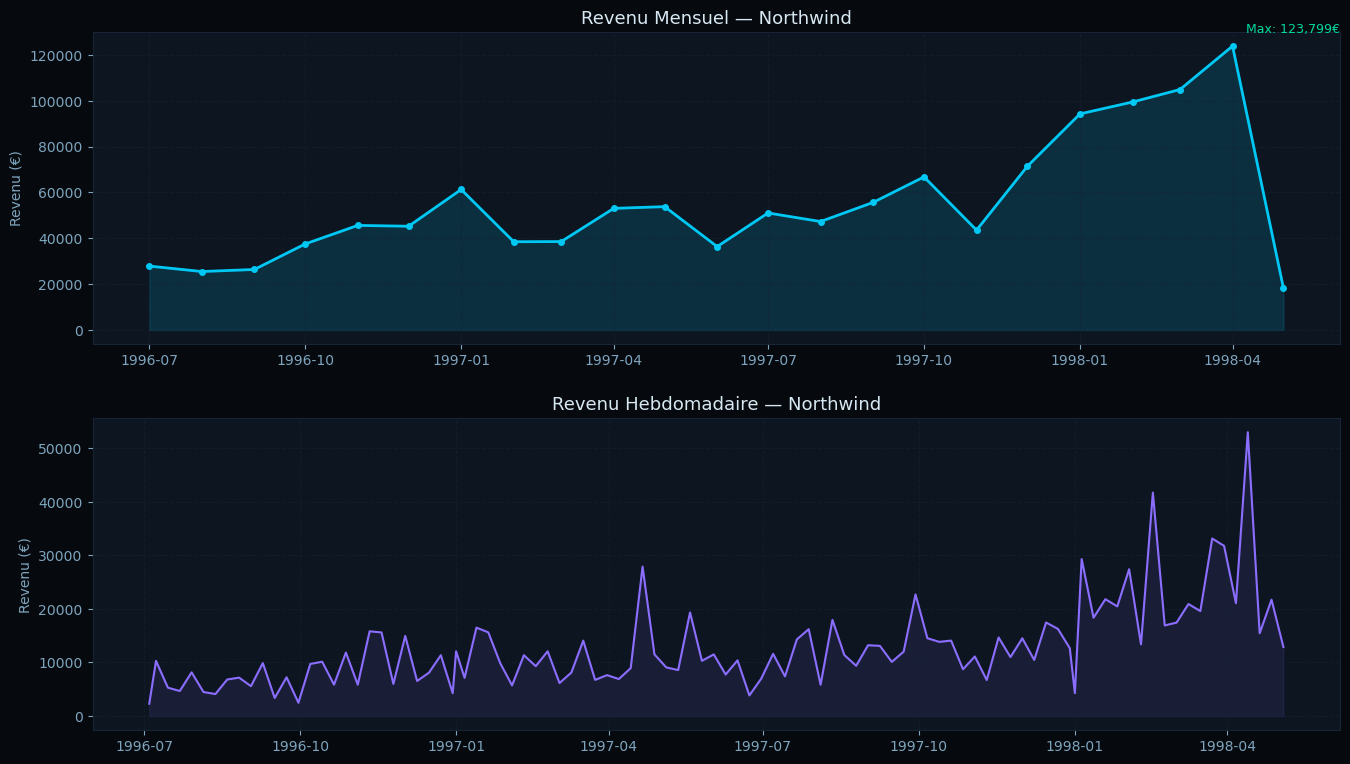

✅ Graphique sauvegardé → /tmp/northwind_series.png


In [13]:
# ── Visualisation ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax1 = axes[0]
ax1.plot(df_monthly.index, df_monthly['revenu'], color='#00c8f5', lw=2, marker='o', ms=4)
ax1.fill_between(df_monthly.index, df_monthly['revenu'], alpha=0.15, color='#00c8f5')
ax1.set_title('Revenu Mensuel — Northwind', color='#d8e8f2', fontsize=13)
ax1.set_ylabel('Revenu (€)', color='#7ea4be')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.grid(True)
idx_max = df_monthly['revenu'].idxmax()
ax1.annotate(f'Max: {df_monthly["revenu"].max():,.0f}€',
             xy=(idx_max, df_monthly['revenu'].max()),
             xytext=(10,10), textcoords='offset points', color='#00d9a0', fontsize=9)

ax2 = axes[1]
ax2.plot(df_weekly.index, df_weekly['revenu'], color='#8b6eff', lw=1.5)
ax2.fill_between(df_weekly.index, df_weekly['revenu'], alpha=0.1, color='#8b6eff')
ax2.set_title('Revenu Hebdomadaire — Northwind', color='#d8e8f2', fontsize=13)
ax2.set_ylabel('Revenu (€)', color='#7ea4be')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.grid(True)

plt.tight_layout(pad=2)
plt.savefig('/tmp/northwind_series.png', dpi=120, bbox_inches='tight', facecolor='#060a0e')
plt.show()
print('✅ Graphique sauvegardé → /tmp/northwind_series.png')

In [14]:
# ── Qualité des données ───────────────────────────────────────────
print('='*50)
print('  RAPPORT QUALITÉ')
print('='*50)

missing = df_monthly['revenu'].isna().sum()
print(f'\n📌 Valeurs manquantes : {missing}')

full_range = pd.date_range(df_monthly.index.min(), df_monthly.index.max(), freq='MS')
gaps = full_range.difference(df_monthly.index)
print(f'📌 Mois manquants     : {len(gaps)}')
if len(gaps): print(f'   → {list(gaps.strftime("%Y-%m"))}')

mean_r, std_r = df_monthly['revenu'].mean(), df_monthly['revenu'].std()
outliers = df_monthly[np.abs(df_monthly['revenu'] - mean_r) > 3 * std_r]
print(f'📌 Outliers (>3σ)     : {len(outliers)}')

n_m, n_w = len(df_monthly), len(df_weekly)
print(f'\n📌 Décision LSTM :')
print(f'   Mensuel  : {n_m} pts → LSTM {"✅ OK" if n_m>=50 else "⚠️ LIMITÉ"}')
print(f'   Hebdo    : {n_w} pts → LSTM {"✅ OK" if n_w>=80 else "⚠️ INSUFFISANT"}')
GRANULARITE = 'monthly' if n_m >= 50 else 'weekly'
print(f'\n→ Granularité retenue pour LSTM : {GRANULARITE}')

  RAPPORT QUALITÉ

📌 Valeurs manquantes : 0
📌 Mois manquants     : 0
📌 Outliers (>3σ)     : 0

📌 Décision LSTM :
   Mensuel  : 23 pts → LSTM ⚠️ LIMITÉ
   Hebdo    : 99 pts → LSTM ✅ OK

→ Granularité retenue pour LSTM : weekly


In [15]:
# ── Test ADF (Stationnarité) ──────────────────────────────────────
def test_adf(series, nom):
    result = adfuller(series.dropna(), autolag='AIC')
    stat, pval = result[0], result[1]
    print(f'\n📊 ADF — {nom}')
    print(f'   p-value : {pval:.4f}  →  {"✅ STATIONNAIRE" if pval<=0.05 else "❌ NON-STATIONNAIRE → d=1 pour SARIMA"}')
    return pval <= 0.05

test_adf(df_monthly['revenu'], 'Revenu Mensuel (brut)')
test_adf(df_monthly['revenu'].diff().dropna(), 'Revenu Mensuel (différencié d=1)')


📊 ADF — Revenu Mensuel (brut)
   p-value : 0.0000  →  ✅ STATIONNAIRE

📊 ADF — Revenu Mensuel (différencié d=1)
   p-value : 0.0023  →  ✅ STATIONNAIRE


True

  SPLIT TRAIN / TEST

Mensuel  — Train: 18 pts | Test: 5 pts
           1996-07 → 1997-12 | 1998-01 → 1998-05

Hebdo    — Train: 79 pts | Test: 20 pts


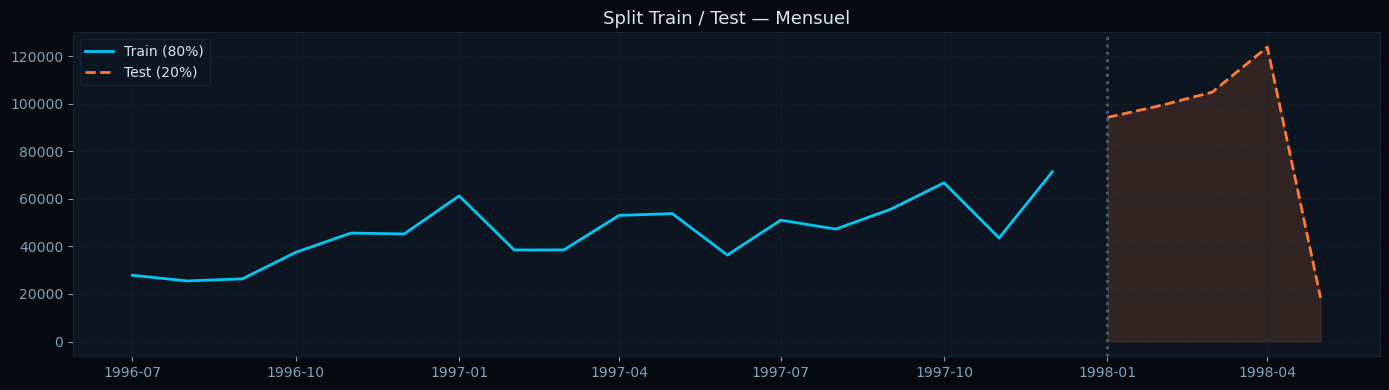

In [16]:
# ── Split Train / Test 80/20 chronologique ────────────────────────
split_m = int(len(df_monthly) * 0.8)
split_w = int(len(df_weekly)  * 0.8)
train_m, test_m = df_monthly.iloc[:split_m], df_monthly.iloc[split_m:]
train_w, test_w = df_weekly.iloc[:split_w],  df_weekly.iloc[split_w:]

print('='*50)
print('  SPLIT TRAIN / TEST')
print('='*50)
print(f'\nMensuel  — Train: {len(train_m)} pts | Test: {len(test_m)} pts')
print(f'           {train_m.index.min().strftime("%Y-%m")} → {train_m.index.max().strftime("%Y-%m")} | {test_m.index.min().strftime("%Y-%m")} → {test_m.index.max().strftime("%Y-%m")}')
print(f'\nHebdo    — Train: {len(train_w)} pts | Test: {len(test_w)} pts')

# Visualiser
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_m.index, train_m['revenu'], color='#00c8f5', lw=2, label='Train (80%)')
ax.plot(test_m.index,  test_m['revenu'],  color='#ff7a35', lw=2, label='Test (20%)', linestyle='--')
ax.axvline(x=test_m.index.min(), color='#45657e', linestyle=':', lw=2)
ax.fill_between(test_m.index, test_m['revenu'], alpha=0.15, color='#ff7a35')
ax.set_title('Split Train / Test — Mensuel', color='#d8e8f2', fontsize=13)
ax.legend(facecolor='#0d1520', edgecolor='#182336', labelcolor='#d8e8f2')
ax.grid(True)
plt.tight_layout()
plt.savefig('/tmp/split_train_test.png', dpi=120, bbox_inches='tight', facecolor='#060a0e')
plt.show()

In [17]:
# ── Sauvegarde CSV ────────────────────────────────────────────────
df_monthly.to_csv('/tmp/northwind_monthly.csv')
df_weekly.to_csv('/tmp/northwind_weekly.csv')
train_m.to_csv('/tmp/northwind_monthly_train.csv')
test_m.to_csv('/tmp/northwind_monthly_test.csv')
train_w.to_csv('/tmp/northwind_weekly_train.csv')
test_w.to_csv('/tmp/northwind_weekly_test.csv')

print('✅ Fichiers sauvegardés dans /tmp/')
print(f'   northwind_monthly.csv       ({len(df_monthly)} pts)')
print(f'   northwind_weekly.csv        ({len(df_weekly)} pts)')
print(f'   northwind_monthly_train.csv ({len(train_m)} pts)')
print(f'   northwind_monthly_test.csv  ({len(test_m)} pts)')
print()
print('→ Prochain notebook : Notebook 2 — SARIMA')

✅ Fichiers sauvegardés dans /tmp/
   northwind_monthly.csv       (23 pts)
   northwind_weekly.csv        (99 pts)
   northwind_monthly_train.csv (18 pts)
   northwind_monthly_test.csv  (5 pts)

→ Prochain notebook : Notebook 2 — SARIMA
